<a href="https://colab.research.google.com/github/Froststar16/canopy-watch-hyderabad/blob/main/notebooks/03_lst_correlation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3 — Land Surface Temperature + NDVI Correlation (Urban Heat Island)

This notebook picks up where `02_ward_level_ndvi.ipynb` left off. It:

1. Reloads the 155 GHMC ward boundaries (same repair pipeline as Phase 2)
2. Computes yearly **land surface temperature (LST)** per ward from Landsat 8/9 thermal data
3. Merges LST with the Phase 2 NDVI-by-ward table
4. Checks whether wards that lost canopy also got measurably hotter — the actual urban heat island signal
5. Flags the wards with the worst combined trend (canopy down + temperature up) as a hotspot shortlist

## Why Landsat, and why this is straightforward

Sentinel-2 (used for NDVI) has no thermal sensor, so LST has to come from Landsat. The good news: Landsat's
**Collection 2, Level-2** products already include a processed, ready-to-use surface temperature band
(`ST_B10`) — USGS has done the atmospheric correction and emissivity handling for you. All you do is apply
a documented scale factor to convert the raw digital numbers to Kelvin, then to Celsius. No manual
radiative-transfer math needed.

Two practical differences from the NDVI pipeline worth knowing before you run this:

- **Coarser resolution.** Landsat's thermal band is delivered at 30 m (vs. Sentinel-2's 10 m), so
  `reduceRegions` below uses `scale=30` instead of `scale=10`. A ward's "mean LST" is therefore a coarser
  average than its "mean NDVI" — fine for ward-level comparison, just not apples-to-apples pixel-for-pixel.
- **Two satellites merged.** Landsat 8 has flown since 2013; Landsat 9 (a near-identical twin) only launched
  in September 2021. The code below merges both collections — years before Landsat 9 existed simply use
  Landsat 8 only, and `ee.ImageCollection.merge()` handles that transparently.

## 1. Setup

In [1]:
!pip install geopandas geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 38.5 MB/s eta 0:00:00


In [2]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as scipy_stats
import xml.etree.ElementTree as ET
from shapely.geometry import Polygon, MultiPolygon
from shapely.validation import make_valid
from shapely.geometry.polygon import orient

# Auth + init — same Cloud project as Phases 1 and 2
ee.Authenticate()
ee.Initialize(project='canopy-watch-hyderabad')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
OUTPUT_DIR = '/content/drive/MyDrive/canopy-watch-hyderabad/outputs'
DATA_DIR = '/content/drive/MyDrive/canopy-watch-hyderabad/data'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

Mounted at /content/drive


## 2. Reload the ward boundaries

Same KML loader and geometry-repair pipeline as `02_ward_level_ndvi.ipynb` — reproduced here so this
notebook can run standalone (Earth Engine sessions don't persist between notebooks). If you saved
`ghmc_wards.kml` to `data/` in Phase 2, this reads it straight from Drive.

In [4]:
NS = {"kml": "http://www.opengis.net/kml/2.2"}

def load_kml_as_gdf(path):
    """Robust KML loader: try geopandas/GDAL first, fall back to manual XML parsing."""
    for kwargs in ({}, {"driver": "KML"}, {"driver": "LIBKML"}):
        try:
            gdf = gpd.read_file(path, **kwargs)
            if len(gdf) > 0:
                print(f"Loaded '{path}' via geopandas ({kwargs or 'default driver'}): {len(gdf)} feature(s)")
                return gdf
        except Exception:
            pass

    print(f"GDAL KML driver unavailable — falling back to manual parser for '{path}'")
    tree = ET.parse(path)
    root = tree.getroot()
    records, geoms = [], []
    for placemark in root.iter("{http://www.opengis.net/kml/2.2}Placemark"):
        props = {}
        for sd in placemark.iter("{http://www.opengis.net/kml/2.2}SimpleData"):
            props[sd.get("name")] = sd.text
        polygons = []
        for poly_el in placemark.iter("{http://www.opengis.net/kml/2.2}Polygon"):
            outer = poly_el.find(".//kml:outerBoundaryIs/kml:LinearRing/kml:coordinates", NS)
            if outer is None or not outer.text:
                continue
            ring = []
            for triple in outer.text.strip().split():
                lon, lat = map(float, triple.split(",")[:2])
                ring.append((lon, lat))
            if len(ring) >= 4:
                polygons.append(Polygon(ring))
        if not polygons:
            continue
        geom = polygons[0] if len(polygons) == 1 else MultiPolygon(polygons)
        geoms.append(geom)
        records.append(props if props else {"id": placemark.get("id")})
    gdf = gpd.GeoDataFrame(records, geometry=geoms, crs="EPSG:4326")
    print(f"Loaded '{path}' via manual parser: {len(gdf)} feature(s)")
    return gdf


def _polygons_only(geom):
    """Flatten a Polygon/MultiPolygon/GeometryCollection down to a list of Polygons."""
    if geom.geom_type == 'Polygon':
        return [geom]
    elif geom.geom_type == 'MultiPolygon':
        return list(geom.geoms)
    elif geom.geom_type == 'GeometryCollection':
        out = []
        for g in geom.geoms:
            out.extend(_polygons_only(g))
        return out
    return []


def clean_geometry(geom):
    """Repair invalid geometry and enforce GeoJSON-compliant ring winding (CCW exterior)."""
    if geom is None or geom.is_empty:
        return None
    if not geom.is_valid:
        geom = make_valid(geom)
    polys = [p for p in _polygons_only(geom) if p.area > 0]
    if not polys:
        return None
    polys = [orient(p, sign=1.0) for p in polys]
    return polys[0] if len(polys) == 1 else MultiPolygon(polys)


def report_and_clean(gdf, name):
    n_before_invalid = (~gdf.geometry.is_valid).sum()
    gdf = gdf.copy()
    gdf['geometry'] = gdf.geometry.apply(clean_geometry)
    n_dropped = gdf['geometry'].isna().sum()
    gdf = gdf[gdf['geometry'].notna()].reset_index(drop=True)
    print(f"{name}: {n_before_invalid} invalid geometrie(s) repaired, {n_dropped} unrepairable feature(s) dropped, {len(gdf)} remain.")
    return gdf

In [5]:
wards_kml_path = f'{DATA_DIR}/ghmc_wards.kml'

wards_gdf = load_kml_as_gdf(wards_kml_path)
wards_gdf = wards_gdf.set_crs("EPSG:4326", allow_override=True)

# Split "127-RANGAREDDY NAGAR" into ward number + name, same as Phase 2
split_ward = wards_gdf['ward'].str.split('-', n=1, expand=True)
wards_gdf['ward_no'] = split_ward[0].str.strip()
wards_gdf['ward_name'] = split_ward[1].str.strip()
wards_gdf = wards_gdf[['ward_no', 'ward_name', 'CIRCLE', 'ZONE', 'geometry']].copy()
wards_gdf.columns = ['ward_no', 'ward_name', 'circle', 'zone', 'geometry']

wards_gdf = report_and_clean(wards_gdf, 'wards_gdf')
wards_gdf.head()

Loaded '/content/drive/MyDrive/canopy-watch-hyderabad/data/ghmc_wards.kml' via geopandas (default driver): 155 feature(s)
wards_gdf: 0 invalid geometrie(s) repaired, 0 unrepairable feature(s) dropped, 155 remain.


,ward_no,ward_name,circle,zone,geometry
0,127,RANGAREDDY NAGAR,25-QUTUBULLAPUR,KUKATPALLY ZONE,"POLYGON ((78.45031 17.48797, 78.44762 17.48849..."
1,119,OLD BOWENPALLY,24-KUKATPALLY,KUKATPALLY ZONE,"POLYGON ((78.47869 17.48565, 78.4781 17.48566,..."
2,145,SEETHAPHALMANDI,29-SECUNDERABAD,SECUNDERABAD ZONE,"POLYGON ((78.52062 17.4268, 78.52054 17.42682,..."
3,146,BOUDHA NAGAR,29-SECUNDERABAD,SECUNDERABAD ZONE,"POLYGON ((78.52018 17.4193, 78.52008 17.41931,..."
4,147,BANSILALPET,30-BEGUMPET,SECUNDERABAD ZONE,"POLYGON ((78.50605 17.43299, 78.50595 17.43268..."


## 3. Load into Earth Engine

Same approach as Phase 2: convert to a `FeatureCollection`, and build the citywide boundary as the
dissolved union of the 155 wards (the standalone GHMC boundary KML never ingested cleanly, so Phase 2
dropped it in favor of this — see the Phase 2 notes if you're curious why).

In [6]:
wards_ee = geemap.geopandas_to_ee(wards_gdf)
ghmc_geometry = wards_ee.union(1).first().geometry()

Map = geemap.Map()
Map.centerObject(ghmc_geometry, 10)
Map.addLayer(wards_ee.style(color='green', fillColor='00000000', width=1), {}, 'Wards')
Map

Map(center=[17.427065662802733, 78.45484948679848], controls=(WidgetControl(options=['position', 'transparent_…

## 4. Land surface temperature pipeline (Landsat 8/9, Collection 2 Level-2)

- **Cloud/shadow/cirrus masking** via the `QA_PIXEL` band, same bit-flag approach as the Sentinel-2 cloud
  mask in earlier notebooks, just different bit positions (Landsat Collection 2's QA_PIXEL schema).
- **Scale factor**: `ST_B10 * 0.00341802 + 149.0` converts the raw band to Kelvin (per USGS's Collection 2
  documentation); subtracting 273.15 gives Celsius.
- **Landsat 8 + 9 merged** per year, then a median composite (mirrors the `median()` composite Phase 2 used
  for NDVI — robust to residual cloud noise from imperfect masking).

In [7]:
def mask_landsat_clouds(image):
    qa = image.select('QA_PIXEL')
    dilated_cloud_bit = 1 << 1
    cirrus_bit = 1 << 2
    cloud_bit = 1 << 3
    cloud_shadow_bit = 1 << 4
    mask = (qa.bitwiseAnd(dilated_cloud_bit).eq(0)
            .And(qa.bitwiseAnd(cirrus_bit).eq(0))
            .And(qa.bitwiseAnd(cloud_bit).eq(0))
            .And(qa.bitwiseAnd(cloud_shadow_bit).eq(0)))
    return image.updateMask(mask)


def _prep_lst(image):
    image = mask_landsat_clouds(image)
    lst_c = image.select('ST_B10').multiply(0.00341802).add(149.0).subtract(273.15).rename('LST_C')
    return image.addBands(lst_c)


def get_lst_collection(region, start_date, end_date, cloud_thresh=30):
    l8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
          .filterBounds(region)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUD_COVER', cloud_thresh))
          .map(_prep_lst))
    l9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
          .filterBounds(region)
          .filterDate(start_date, end_date)
          .filter(ee.Filter.lt('CLOUD_COVER', cloud_thresh))
          .map(_prep_lst))
    return l8.merge(l9)


def yearly_lst_image(year, region):
    start, end = f'{year}-01-01', f'{year}-12-31'
    collection = get_lst_collection(region, start, end)
    composite = collection.select('LST_C').median()
    return composite

YEARS = list(range(2016, 2027))  # matches the NDVI table's year range from Phase 2

## 5. Ward-level yearly LST

Same `reduceRegions` pattern as Phase 2's ward NDVI loop — one server-side call per year covering all 155
wards, rather than looping per-ward client-side. Note `scale=30` here (Landsat's native thermal resolution),
vs. `scale=10` for the NDVI table.

In [8]:
lst_rows = []
for year in YEARS:
    lst = yearly_lst_image(year, ghmc_geometry)
    stats = lst.reduceRegions(
        collection=wards_ee,
        reducer=ee.Reducer.mean(),
        scale=30,
        tileScale=4
    )
    features = stats.getInfo()['features']
    for f in features:
        props = f['properties']
        lst_rows.append({
            'year': year,
            'ward_no': props.get('ward_no'),
            'mean_lst_c': props.get('mean')
        })
    print(f'{year}: {len(features)} wards processed')

lst_df = pd.DataFrame(lst_rows)
lst_df.to_csv(f'{OUTPUT_DIR}/hyderabad_lst_by_ward.csv', index=False)
lst_df.head()

2016: 155 wards processed
2017: 155 wards processed
2018: 155 wards processed
2019: 155 wards processed
2020: 155 wards processed
2021: 155 wards processed
2022: 155 wards processed
2023: 155 wards processed
2024: 155 wards processed
2025: 155 wards processed
2026: 155 wards processed


,year,ward_no,mean_lst_c
0,2016,127,39.698150
1,2016,119,39.052895
2,2016,145,41.159195
3,2016,146,41.510924
4,2016,147,40.433743


## 6. Merge with the Phase 2 NDVI table

Loads `hyderabad_ndvi_by_ward.csv` from Phase 2 and joins on `(year, ward_no)`.

In [9]:
ndvi_df = pd.read_csv(f'{OUTPUT_DIR}/hyderabad_ndvi_by_ward.csv')
ndvi_df['ward_no'] = ndvi_df['ward_no'].astype(str)
lst_df['ward_no'] = lst_df['ward_no'].astype(str)

merged_df = ndvi_df.merge(lst_df, on=['year', 'ward_no'], how='inner')
merged_df.to_csv(f'{OUTPUT_DIR}/hyderabad_ndvi_lst_by_ward.csv', index=False)

print(f'{len(merged_df)} ward-year rows merged (from {len(ndvi_df)} NDVI rows, {len(lst_df)} LST rows)')
merged_df.head()

1705 ward-year rows merged (from 1705 NDVI rows, 1705 LST rows)


,year,ward_no,ward_name,circle,zone,mean_ndvi,mean_lst_c
0,2016,127,RANGAREDDY NAGAR,25-QUTUBULLAPUR,KUKATPALLY ZONE,0.149990,39.698150
1,2016,119,OLD BOWENPALLY,24-KUKATPALLY,KUKATPALLY ZONE,0.151146,39.052895
2,2016,145,SEETHAPHALMANDI,29-SECUNDERABAD,SECUNDERABAD ZONE,0.102412,41.159195
3,2016,146,BOUDHA NAGAR,29-SECUNDERABAD,SECUNDERABAD ZONE,0.089863,41.510924
4,2016,147,BANSILALPET,30-BEGUMPET,SECUNDERABAD ZONE,0.152914,40.433743


## 7. Does more canopy mean cooler wards?

Pearson correlation between `mean_ndvi` and `mean_lst_c` across every ward-year in the merged table. A
negative, statistically significant `r` is the expected urban-heat-island signal: greener wards run cooler.

Pearson r = -0.194  (p = 5.97e-16, n = 1705 ward-years)


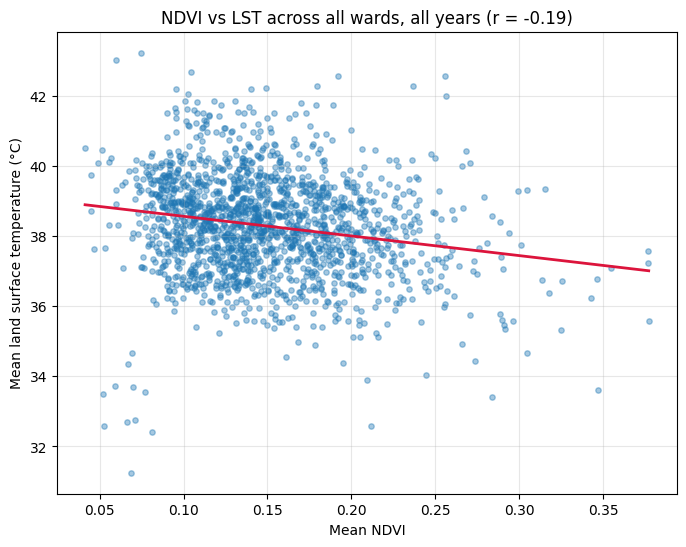

In [10]:
valid = merged_df.dropna(subset=['mean_ndvi', 'mean_lst_c'])
r, p = scipy_stats.pearsonr(valid['mean_ndvi'], valid['mean_lst_c'])
print(f'Pearson r = {r:.3f}  (p = {p:.2e}, n = {len(valid)} ward-years)')

plt.figure(figsize=(8, 6))
plt.scatter(valid['mean_ndvi'], valid['mean_lst_c'], alpha=0.4, s=15)
fit = np.polyfit(valid['mean_ndvi'], valid['mean_lst_c'], 1)
xline = np.linspace(valid['mean_ndvi'].min(), valid['mean_ndvi'].max(), 100)
plt.plot(xline, np.poly1d(fit)(xline), color='crimson', linewidth=2)
plt.xlabel('Mean NDVI')
plt.ylabel('Mean land surface temperature (°C)')
plt.title(f'NDVI vs LST across all wards, all years (r = {r:.2f})')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/ndvi_lst_scatter.png', dpi=150)
plt.show()

## 8. Heat-risk shortlist — wards where canopy is dropping *and* temperature is rising

First year vs. most recent year with complete data, per ward, for both NDVI and LST. A simple combined
score surfaces wards where both trends point the wrong way — the actual hotspot candidates for a
closer look (and eventually for the Phase 4 comparison against Haritha Haram's claimed plantation sites).

In [11]:
first_year, last_year = merged_df['year'].min(), merged_df['year'].max()

ndvi_pivot = merged_df.pivot_table(index=['ward_no', 'ward_name', 'zone'], columns='year', values='mean_ndvi')
lst_pivot = merged_df.pivot_table(index=['ward_no', 'ward_name', 'zone'], columns='year', values='mean_lst_c')

risk_df = pd.DataFrame({
    'ndvi_change': ndvi_pivot[last_year] - ndvi_pivot[first_year],
    'lst_change_c': lst_pivot[last_year] - lst_pivot[first_year],
})

# NDVI lives on a 0-1 scale, LST change is in whole degrees C — scale NDVI change up
# so a "meaningful" move in either variable contributes comparably to the score.
# This weighting is a starting point, not a validated formula — worth revisiting once
# you see the actual distribution of changes.
risk_df['heat_risk_score'] = risk_df['lst_change_c'] - (risk_df['ndvi_change'] * 10)
risk_df = risk_df.sort_values('heat_risk_score', ascending=False)
risk_df.to_csv(f'{OUTPUT_DIR}/hyderabad_heat_risk_wards.csv')

print(f"Top 15 heat-risk wards, {first_year} -> {last_year} (declining canopy + rising temperature):")
display(risk_df.head(15))

Top 15 heat-risk wards, 2016 -> 2026 (declining canopy + rising temperature):


,,,ndvi_change,lst_change_c,heat_risk_score
ward_no,ward_name,zone,,,
115,BALAJI NAGAR,KUKATPALLY ZONE,-0.085399,1.517550,2.371544
99,VENGALRAO NAGAR,SERILINGAMPALLY ZONE,-0.049887,1.404690,1.903565
116,ALLAPUR,KUKATPALLY ZONE,-0.065281,1.232712,1.885524
68,TOLICHOWKI,KHAIRATHABAD ZONE,-0.087588,0.820015,1.695892
112,RAMACHANDRAPURAM,SERILINGAMPALLY ZONE,-0.073568,0.869622,1.605298
92,VENKATESHWARA COLONY,KHAIRATHABAD ZONE,-0.064817,0.920650,1.568824
96,YOUSUFGUDA,SERILINGAMPALLY ZONE,-0.034388,1.135891,1.479767
120,BALA NAGAR,KUKATPALLY ZONE,-0.070617,0.750065,1.456232
118,FATEH NAGAR,KUKATPALLY ZONE,-0.034119,1.034643,1.375831


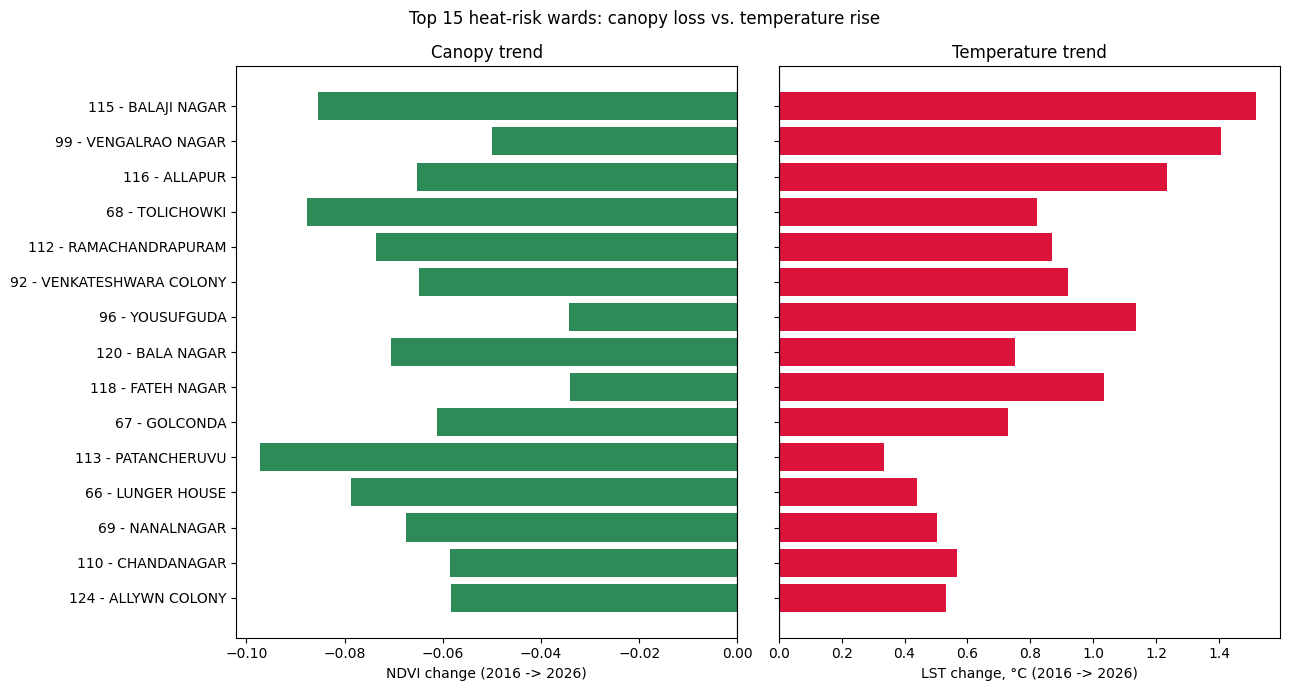

In [12]:
top_risk = risk_df.head(15).reset_index()
top_risk['label'] = top_risk['ward_no'] + ' - ' + top_risk['ward_name']

fig, axes = plt.subplots(1, 2, figsize=(13, 7), sharey=True)

axes[0].barh(top_risk['label'][::-1], top_risk['ndvi_change'][::-1], color='seagreen')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel(f'NDVI change ({first_year} -> {last_year})')
axes[0].set_title('Canopy trend')

axes[1].barh(top_risk['label'][::-1], top_risk['lst_change_c'][::-1], color='crimson')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel(f'LST change, °C ({first_year} -> {last_year})')
axes[1].set_title('Temperature trend')

plt.suptitle('Top 15 heat-risk wards: canopy loss vs. temperature rise')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/ward_heat_risk.png', dpi=150)
plt.show()

## 9. Optional — spatial view of the latest year's LST

A quick visual sanity check: does the hottest year's thermal map visibly track the low-NDVI wards from
Phase 2's `ward_ndvi_change.png`? Not needed for the analysis above, but useful for the README/portfolio.

In [13]:
latest_lst = yearly_lst_image(last_year, ghmc_geometry)

lst_vis = {
    'min': 25, 'max': 45,
    'palette': ['040274', '30eeb3', 'ffffcc', 'ff8c00', 'd7191c']
}

Map2 = geemap.Map()
Map2.centerObject(ghmc_geometry, 11)
Map2.addLayer(latest_lst.clip(ghmc_geometry), lst_vis, f'LST {last_year} (°C)')
Map2.addLayer(wards_ee.style(color='black', fillColor='00000000', width=1), {}, 'Wards')
Map2.add_colorbar(lst_vis, label='Land surface temperature (°C)')
Map2

Map(center=[17.427065662802605, 78.45484948679844], controls=(WidgetControl(options=['position', 'transparent_…

## Next steps

- Copy `hyderabad_lst_by_ward.csv`, `hyderabad_ndvi_lst_by_ward.csv`, `hyderabad_heat_risk_wards.csv`,
  `ndvi_lst_scatter.png`, and `ward_heat_risk.png` from Drive into the repo's `outputs/` folder.
- Update the README: mark Phase 3 ✅, add the Pearson `r` result and the scatter plot, note the 30 m vs.
  10 m resolution difference between LST and NDVI.
- Phase 4: source public Haritha Haram sapling-count data (state reports / RTI) and compare it against
  the wards in `hyderabad_heat_risk_wards.csv` — do the wards claiming the most plantation activity
  actually show the canopy gains this pipeline measures?
- Phase 5: once Phase 4 is done, the Streamlit/leafmap dashboard has three ward-level tables to draw on
  (NDVI, LST, and eventually Haritha Haram claims) — worth designing the dashboard's views around that.